### 画像読込

In [1]:
# 訓練データとテストデータの画像を読み込む
# （サイズは縦横96pxにリサイズする）
import tensorflow as tf

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "dog_cat_photos/train",
    image_size=(96, 96),
    label_mode="binary",
    batch_size=32,
    shuffle=True
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "dog_cat_photos/test",
    image_size=(96, 96),
    label_mode="binary",
    batch_size=32,
    shuffle=False
)

Found 300 files belonging to 2 classes.
Found 100 files belonging to 2 classes.


In [ ]:
# 分類名（cat／dog）をリストとして格納する
class_names = train_dataset.class_names
class_names

['cat', 'dog']

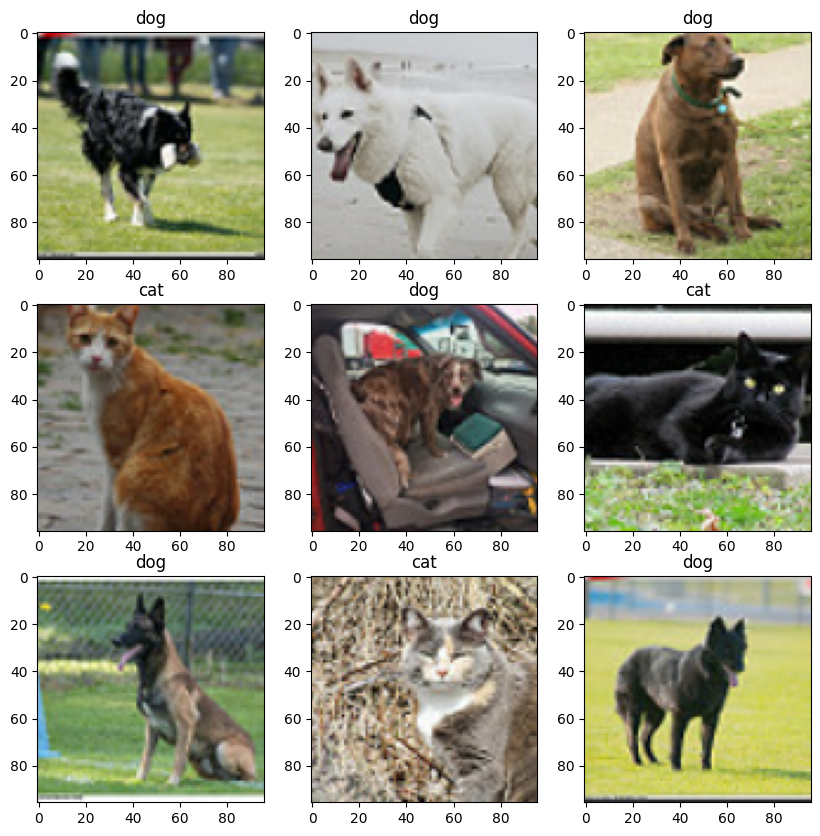

In [3]:
# 訓練データの一部を表示して確認
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

### データ水増し

In [4]:
# 画像の水増しをする関数の定義
def flip_left_right(image, label):   # 左右反転
    image = tf.image.flip_left_right(image)
    return image, label

def flip_up_down(image, label):      # 上下反転
    image = tf.image.flip_up_down(image)
    return image, label

def rot90(image, label):             # 反時計回りに90度回転
    image = tf.image.rot90(image)
    return image, label

def rot180(image, label):            # 反時計回りに180度回転
    image = tf.image.rot90(image, k=2)
    return image, label

def rot270(image, label):            # 反時計回りに270度回転
    image = tf.image.rot90(image, k=3)
    return image, label

In [5]:
# 画像の水増し処理の実行
train_dataset_lr     = train_dataset.map(flip_left_right)
train_dataset_ud     = train_dataset.map(flip_up_down)
train_dataset_rot90  = train_dataset.map(rot90)
train_dataset_rot180 = train_dataset.map(rot180)
train_dataset_rot270 = train_dataset.map(rot270)

In [6]:
# 水増ししたデータを訓練データに追加する
train_dataset = train_dataset.concatenate(train_dataset_lr)
train_dataset = train_dataset.concatenate(train_dataset_ud)
train_dataset = train_dataset.concatenate(train_dataset_rot90)
train_dataset = train_dataset.concatenate(train_dataset_rot180)
train_dataset = train_dataset.concatenate(train_dataset_rot270)

In [7]:
# データをシャッフルする
train_dataset = train_dataset.shuffle(32)

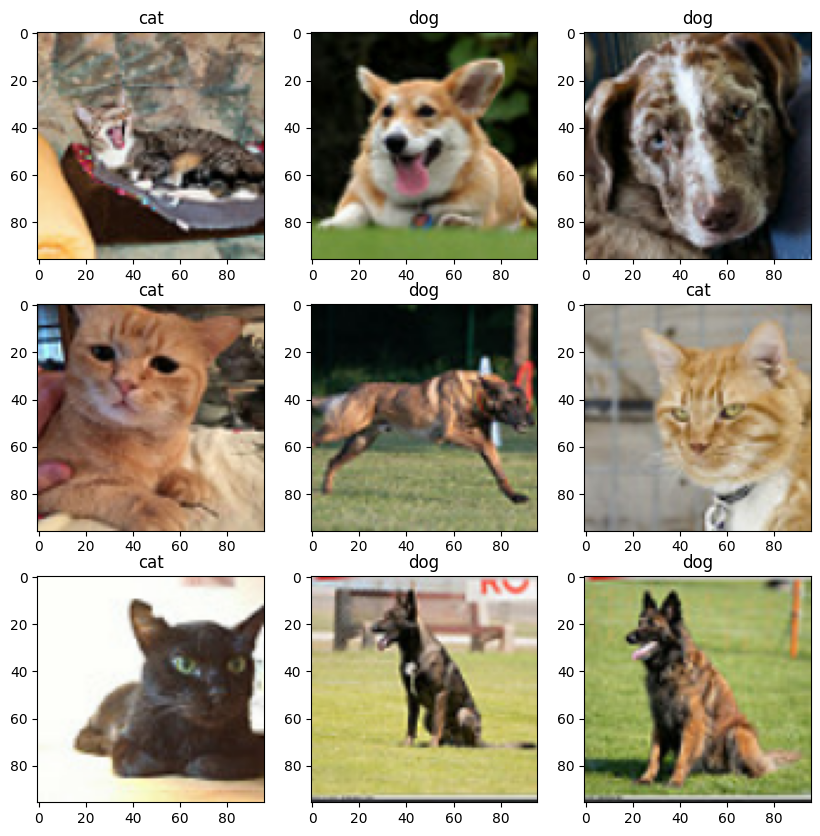

In [8]:
# 訓練データの一部を表示して確認
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

#### MobileNetV2の学習済みモデル読込

In [9]:
# MobileNetV2モデルを作成する
input_layer = tf.keras.Input(shape=(96, 96, 3))   # 入力層
l_layer = tf.keras.applications.mobilenet_v2.preprocess_input(input_layer)   # 前処理（正規化）をする層

base_model = tf.keras.applications.mobilenet_v2.MobileNetV2(
    input_shape=(96, 96, 3),
    input_tensor=l_layer,
    include_top=False,
    weights="imagenet",
    pooling='avg'
)
base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


### 出力層作成・モデル完成

In [12]:
# Dense層を追加する
output_layer = tf.keras.layers.Dense(1, activation='sigmoid')

# base_modelに先ほどのDense層を追加したモデルを作成する
model = tf.keras.Sequential([
    base_model,
    output_layer
])

# modelをcompileする
model.compile(optimizer="adam",
              loss='binary_crossentropy',
              metrics=["accuracy"])

### 学習

In [13]:
# modelに学習させる
model.fit(train_dataset, epochs=20)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - accuracy: 0.8072 - loss: 0.4034
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step - accuracy: 0.9333 - loss: 0.1878
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step - accuracy: 0.9544 - loss: 0.1394
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - accuracy: 0.9633 - loss: 0.1125
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - accuracy: 0.9767 - loss: 0.0911
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 132ms/step - accuracy: 0.9822 - loss: 0.0771
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step - accuracy: 0.9872 - loss: 0.0666
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - accuracy: 0.9911 - loss: 0.0573
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 131ms/step - accuracy: 0.9939 - loss: 0.0504
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - accuracy: 0.9956 - loss: 0.0451
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - accuracy: 0.9956 - loss: 0.0397
Epoch 12/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 127ms/st

In [14]:
# テストデータで分類を実行する
pred_data = model.predict(test_dataset)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 343ms/step


In [15]:
# 分類した結果を確認する
pred_data

array([[7.31633091e-03],
       [1.06358482e-03],
       [1.05998210e-04],
       [1.08200395e-04],
       [1.62955548e-03],
       [3.86603107e-03],
       [1.60283962e-04],
       [5.14309329e-04],
       [1.14320114e-03],
       [1.94916633e-04],
       [2.09620674e-04],
       [3.46411504e-02],
       [3.10622650e-04],
       [9.65063199e-02],
       [3.44491069e-04],
       [3.31586780e-04],
       [3.96566451e-01],
       [1.84023939e-03],
       [1.22484460e-03],
       [1.68632498e-04],
       [7.06682331e-05],
       [2.03197310e-03],
       [2.36893960e-04],
       [3.47186229e-04],
       [6.98609233e-01],
       [2.27776458e-04],
       [2.95167975e-03],
       [9.68860346e-04],
       [2.40027785e-01],
       [3.95654561e-03],
       [1.19110965e-03],
       [3.79376173e-01],
       [1.05190957e-05],
       [3.91237962e-04],
       [1.01733080e-03],
       [5.79849839e-01],
       [7.13361576e-02],
       [1.49760672e-05],
       [1.97734125e-03],
       [4.35538794e-04],


In [16]:
# evaluate()でモデルの性能を評価する
model.evaluate(test_dataset)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.9800 - loss: 0.0420


[0.04195939004421234, 0.9800000190734863]